In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
from src.data.load import load_articles, load_customers

articles = load_articles()
customers = load_customers()
print("articles:", articles.shape)
print("customers:", customers.shape)

articles: (105542, 25)
customers: (1371980, 7)


In [2]:
transactions = pd.read_csv(
    "../data/raw/transactions_train.csv",
    usecols=["t_dat", "customer_id", "article_id"],
    dtype={"customer_id": "string", "article_id": "string"},
    parse_dates=["t_dat"],
)
print(transactions.shape)
print(transactions["t_dat"].min(), transactions["t_dat"].max())

(31788324, 3)
2018-09-20 00:00:00 2020-09-22 00:00:00


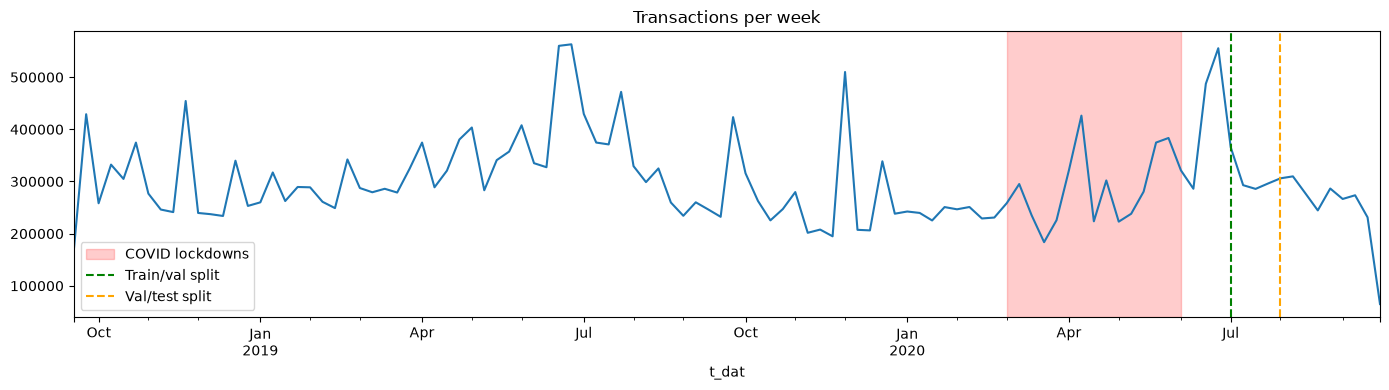

In [3]:
weekly = transactions.set_index("t_dat").resample("W").size()
weekly.plot(figsize=(14, 4), title="Transactions per week")
plt.axvspan("2020-03-01", "2020-06-01", alpha=0.2, color="red", label="COVID lockdowns")
plt.axvline("2020-07-01", color="green", linestyle="--", label="Train/val split")
plt.axvline("2020-08-01", color="orange", linestyle="--", label="Val/test split")
plt.legend()
plt.tight_layout()
plt.show()

Total unique users: 1,362,281
Median transactions per user: 9
Mean transactions per user: 23.3
Users with only 1 transaction: 131,514 (9.7%)
Users with 10+ transactions: 676,044 (49.6%)


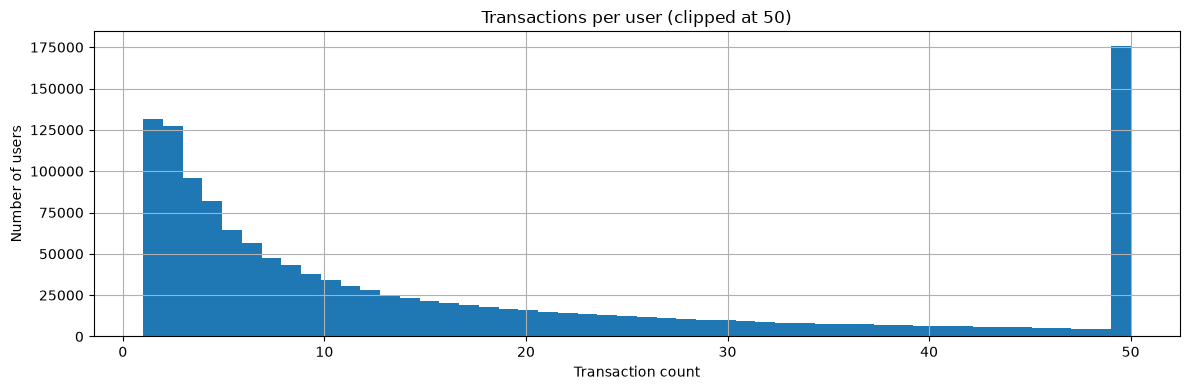

In [4]:
user_counts = transactions.groupby("customer_id").size()
print(f"Total unique users: {user_counts.shape[0]:,}")
print(f"Median transactions per user: {user_counts.median():.0f}")
print(f"Mean transactions per user: {user_counts.mean():.1f}")
print(f"Users with only 1 transaction: {(user_counts == 1).sum():,} ({(user_counts == 1).mean()*100:.1f}%)")
print(f"Users with 10+ transactions: {(user_counts >= 10).sum():,} ({(user_counts >= 10).mean()*100:.1f}%)")

user_counts.clip(upper=50).hist(bins=50, figsize=(12, 4))
plt.title("Transactions per user (clipped at 50)")
plt.xlabel("Transaction count")
plt.ylabel("Number of users")
plt.tight_layout()
plt.show()

Total unique articles: 104,547
Median transactions per article: 65
Mean transactions per article: 304.1
Articles with only 1 transaction: 4,491 (4.3%)
Articles with 100+ transactions: 44,671 (42.7%)


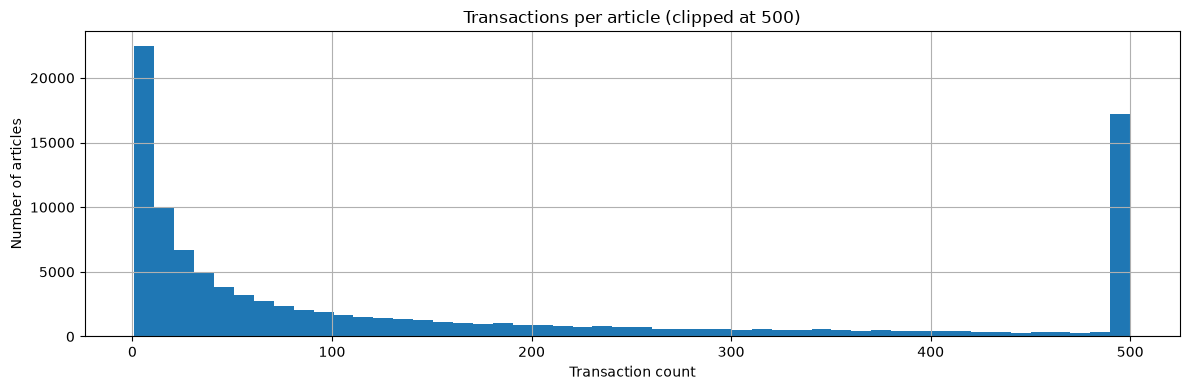

In [5]:
item_counts = transactions.groupby("article_id").size()
print(f"Total unique articles: {item_counts.shape[0]:,}")
print(f"Median transactions per article: {item_counts.median():.0f}")
print(f"Mean transactions per article: {item_counts.mean():.1f}")
print(f"Articles with only 1 transaction: {(item_counts == 1).sum():,} ({(item_counts == 1).mean()*100:.1f}%)")
print(f"Articles with 100+ transactions: {(item_counts >= 100).sum():,} ({(item_counts >= 100).mean()*100:.1f}%)")

item_counts.clip(upper=500).hist(bins=50, figsize=(12, 4))
plt.title("Transactions per article (clipped at 500)")
plt.xlabel("Transaction count")
plt.ylabel("Number of articles")
plt.tight_layout()
plt.show()

In [6]:
repeat = transactions.groupby(["customer_id", "article_id"]).size()
repeat_purchases = (repeat > 1).sum()
total_pairs = len(repeat)
print(f"Unique user-article pairs: {total_pairs:,}")
print(f"Pairs bought more than once: {repeat_purchases:,} ({repeat_purchases/total_pairs*100:.1f}%)")

Unique user-article pairs: 27,306,439
Pairs bought more than once: 3,515,413 (12.9%)


In [7]:
TRAIN_END = pd.Timestamp("2020-07-01")
VAL_END = pd.Timestamp("2020-08-01")
TEST_END = pd.Timestamp("2020-09-08")

train = transactions[transactions["t_dat"] < TRAIN_END]
val = transactions[(transactions["t_dat"] >= TRAIN_END) & (transactions["t_dat"] < VAL_END)]
test = transactions[(transactions["t_dat"] >= VAL_END) & (transactions["t_dat"] < TEST_END)]

print(f"Train: {len(train):,} rows | {train['t_dat'].min().date()} → {train['t_dat'].max().date()} | {len(train)/len(transactions)*100:.1f}%")
print(f"Val:   {len(val):,} rows | {val['t_dat'].min().date()} → {val['t_dat'].max().date()} | {len(val)/len(transactions)*100:.1f}%")
print(f"Test:  {len(test):,} rows | {test['t_dat'].min().date()} → {test['t_dat'].max().date()} | {len(test)/len(transactions)*100:.1f}%")

Train: 28,401,361 rows | 2018-09-20 → 2020-06-30 | 89.3%
Val:   1,351,502 rows | 2020-07-01 → 2020-07-31 | 4.3%
Test:  1,503,494 rows | 2020-08-01 → 2020-09-07 | 4.7%
